# Домашняя работа №1: Метод K-ближайших соседей (KNN)

**Цель:**  
1. Освоить работу алгоритма KNN для задач многоклассовой классификации и регрессии.  
2. Научиться рассчитывать и интерпретировать метрики качества.  


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score, f1_score
)


## Задача 1. KNN для многоклассовой классификации

1 (1 балл). Выберите набор данных из датасетов sklean с несколькими классами (например, `Iris` или `Wine` – оба датасета импортированы в предыдущей ячейке).  
2 (1 балл). Разделите данные на обучающую и тестовую выборки.    
3 (1 балл). Обучите модель `KNeighborsClassifier`.  
4 (1 балл). Постройте confusion_matrix.

5 (1 балл). Посчитайте метрики оценки качества для задач классификации: accuracy, precision, recall, f1-score и сделайте выводы о качестве модели.  

In [39]:
#Задание 1-2
df = load_wine()
type(df)

X = pd.DataFrame(df.data, columns = df.feature_names)
y = pd.DataFrame(df.target, columns = ['targets'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [43]:
#задание 3
#обучаем модель для 5 соседей
from sklearn.neighbors import KNeighborsClassifier

knn_model_5 = KNeighborsClassifier(n_neighbors=5)
knn_model_5.fit(X_train, y_train.values.ravel())


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

def print_metrics(model, X_test, y_test, model_name):
    #Задание 5
    y_pred = model.predict(X_test)

    print(f"Metrics for {model_name}:")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    #будем считать метрики как среднее по всем классам
    print("Precision:", round(precision_score(y_test, y_pred, average='macro'), 4))
    print("Recall:", round(recall_score(y_test, y_pred, average='macro'), 4))
    print("f1-score:", round(f1_score(y_test, y_pred, average='macro'), 4))
    
    # задание 4 построить confusion_matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)
    print("\n")


print_metrics(knn_model_5, X_test, y_test, "KNN model with n_neighbors=5")


Metrics for KNN model with n_neighbors=5:
Accuracy: 0.8056
Precision: 0.8019
Recall: 0.8048
F1-score (macro): 0.8025
Confusion Matrix:
 [[12  0  0]
 [ 0 10  4]
 [ 0  3  7]]




#### Исходя из метрик можно сделать вывод, что в целом модель работает хорошо


## Задача 2. KNN для регрессии

1 (1 балл). Выберите набор данных из датасетов sklearn (например, `load_diabetes` – он импортирован в ячейке с импортами).  
2 (1 балл). Разделите данные на обучающую и тестовую выборки.  
3 (1 балл). Обучите модель `KNeighborsRegressor`.  
4 (1 балл). Посчитайте метрики оценки качества для задач регрессии: `MAE`, `RMSE` и `R²`, сделайте выводы о качестве модели.  
5 (1 балл). Визуализируйте реальные и предсказанные значения на графике.  

In [49]:
# Задание 1
df = load_diabetes()

X = pd.DataFrame(df.data, columns=df.feature_names)
y = pd.DataFrame(df.target, columns=['target'])

X.head()
y.head()

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [51]:
# Задание 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
    )

In [57]:
# задание 3

knn_model_5 = KNeighborsRegressor(n_neighbors=5)
knn_model_5.fit(X_train, y_train.values.ravel())

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [61]:
# задание 4
y_pred = knn_model_5.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"mae: {mae:.3f}")
print(f"rmse: {rmse:.3f}")
print(f"R^2: {r2:.3f}")

mae: 42.771
rmse: 54.946
R^2: 0.430


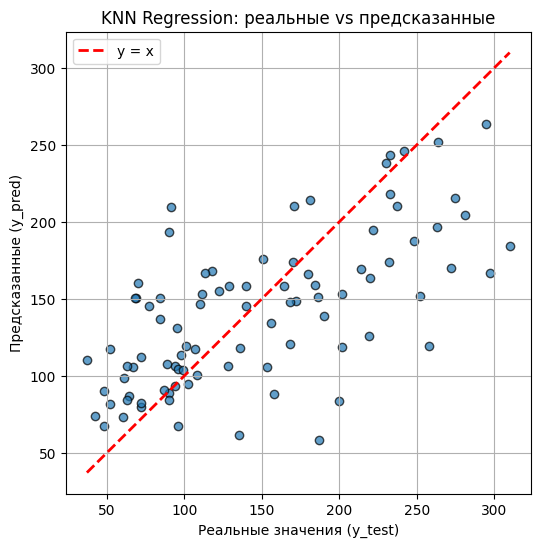

In [76]:

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, edgecolors='k', alpha=0.7)
mn = min(y_test.min().item(), y_pred.min())
mx = max(y_test.max().item(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='y = x')
plt.xlabel('Реальные значения (y_test)')
plt.ylabel('Предсказанные (y_pred)')
plt.title('KNN Regression: реальные vs предсказанные')
plt.legend()
plt.grid(True)
plt.show()




## Задача 3. Анализ влияния числа соседей

1 (1 балл). Изучите, как Accuracy (для классификации) или R² (для регрессии) зависит от k.  
2 (1 балл). Постройте график зависимости выбранной метрики от числа соседей.  
3 (1 балл). Сделайте вывод, как выбор k влияет на качество модели.


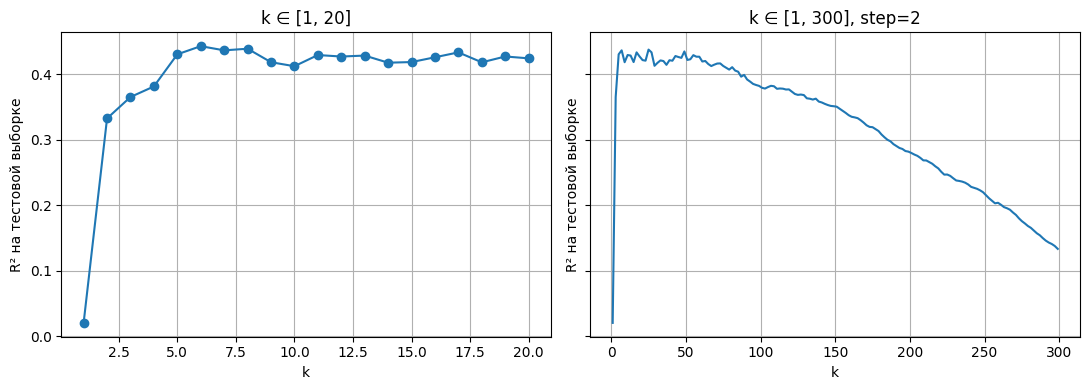

In [75]:
def get_r2(X_train, X_test, y_train, y_test, k):

    knn_regress = KNeighborsRegressor(n_neighbors=k)
    knn_regress.fit(X_train, y_train.values.ravel())

    y_pred = knn_regress.predict(X_test)

    r2  = r2_score(y_test, y_pred)
    return r2

# диапазоны k
k_s_short = np.arange(1, 21, 1)
k_s_long  = np.arange(1, 300, 2)

def eval_k_range(k_s):
    return np.array([get_r2(X_train, X_test, y_train, y_test, k) for k in k_s])

r2_short = eval_k_range(k_s_short)
r2_long  = eval_k_range(k_s_long)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].plot(k_s_short, r2_short, marker='o'); axes[0].set_title('k = [1, 20]')
axes[1].plot(k_s_long,  r2_long);             axes[1].set_title('k = [1, 300]')
for ax in axes:
    ax.set_xlabel('k'); ax.set_ylabel('R^2 на тестовой выборке'); 
    ax.grid()
plt.tight_layout(); 
plt.show()



#### На графике видно, что метрика R^2 быстро растёт при увеличении числа соседей от k = 1 до k = 6, потом держится примерно на уровне 0.47 при k от 6 до 20, а дальше начинает постепенно снижаться.